# Clustering links into regulatory phases

In [ ]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
from focal.io import DatasetPaths

# DatasetPaths.find() walks up from the kernel's working directory to the first
# datasets.yaml (or uses $FOCAL_DATASETS), so it works wherever Jupyter was started.
config = DatasetPaths.find()


In [2]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast

from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [3]:
import dictys

from focal.temporal import *      # classes AND their figures
from focal.utils import *         # gene / state helpers (was utils_custom)

In [4]:
import importlib
import focal.utils, focal.temporal._source, focal.temporal._waves
import focal.temporal._states, focal.temporal._phases, focal.temporal.manager
for _m in (focal.utils, focal.temporal._source, focal.temporal._waves,
           focal.temporal._states, focal.temporal._phases,
           focal.temporal.manager, focal.temporal):
    importlib.reload(_m)


In [5]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file(config.DYNAMIC_H5)

In [6]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [7]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

## Episodic links clustered by regulatory phases present in PB and GC lineages

In [8]:
# Episodically enriched links, derived from the fixed per-branch enrichment tables
# (config.PB / config.GC, one CSV per episode) exactly as in Fig4_2. Enriched TFs are
# the ones the Fig3_2 dotplots call (>=2 LF targets, >=2 downstream genes, min p < 0.05);
# a link is (TF, LF target) from every episode where that TF passes p <= 0.05.
EPISODE_LABELS = ['Ep1', 'Ep2', 'Ep3', 'Ep4']
P_VALUE_THRESHOLD = 0.05

def parse_genes_in_lf(genes_str):
    try:
        if pd.isna(genes_str) or genes_str in ('', '()'):
            return ()
        val = ast.literal_eval(genes_str)
        return val if isinstance(val, tuple) else (val,)
    except Exception:
        return ()

def episodic_lf_links(group, lineage):
    dfs = [pd.read_csv(group[f'ep{i}']) for i in range(1, 5)]
    fig, _, enriched_tfs = plot_tf_episodic_enrichment_dotplot(
        dfs=dfs, episode_labels=EPISODE_LABELS,
        p_value_threshold=P_VALUE_THRESHOLD, min_significance_threshold=P_VALUE_THRESHOLD,
        show_plot=False,
    )
    plt.close(fig)
    rows = []
    for episode, df in zip(EPISODE_LABELS, dfs):
        sub = df[df['TF'].isin(enriched_tfs) & (df['p_value'] <= P_VALUE_THRESHOLD)]
        for _, r in sub.iterrows():
            for g in parse_genes_in_lf(r['genes_in_lf']):
                rows.append({'lineage': lineage, 'episode': episode, 'TF': r['TF'], 'target': g})
    return pd.DataFrame(rows), enriched_tfs

episodic_links_pb, enriched_tfs_pb = episodic_lf_links(config.PB, 'PB')
episodic_links_gc, enriched_tfs_gc = episodic_lf_links(config.GC, 'GC')
episodic_links = pd.concat([episodic_links_pb, episodic_links_gc], ignore_index=True)
print('PB enriched TFs:', enriched_tfs_pb)
print('GC enriched TFs:', enriched_tfs_gc)


Filtered to 35 TFs that meet gene count criteria


Further filtered to 10 TFs that meet significance threshold < 0.05


Filtered to 41 TFs that meet gene count criteria
Further filtered to 11 TFs that meet significance threshold < 0.05
PB enriched TFs: ['IKZF3', 'BHLHE40', 'TFEC', 'REL', 'MEF2C', 'MAX', 'STAT3', 'CREB3L2', 'MEF2A', 'RUNX3']
GC enriched TFs: ['CREB3L2', 'NFATC2', 'IRF1', 'IKZF3', 'RUNX3', 'CDC5L', 'MAX', 'MYC', 'MEF2C', 'STAT6', 'TCF12']


In [9]:
# union of (TF, target) links across both branches and all episodes
episodic_links_tuples = set(zip(episodic_links['TF'], episodic_links['target']))
display(len(episodic_links_tuples))


62

## PB links

In [10]:
import focal.temporal as sd

In [11]:
# Trajectory topology declared once: one segment per branch (PB: node 0 -> 2, GC: node 0 -> 3),
# shared smoothing settings. Each segment gets its own TFForceSource; the force waves,
# the cross-branch validation and the per-branch phases all derive from it.
traj = sd.TrajectorySegments(
    dictys_dynamic_object,
    {'PB': (0, 2), 'GC': (0, 3)},
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)


In [12]:
# episodic links as (TF, target) tuples (built above)
links = sorted(episodic_links_tuples)

# 1) force curves for these links on the PB segment (0 -> 2), cached on its source
waves_pb = traj.waves()['PB']
waves_pb.compute_forces(links)


time_0    time_1    time_2    time_3    time_4    time_5  \
TF      Target                                                                 
BHLHE40 FNDC3A    0.683650  0.691566  0.699384  0.707091  0.714668  0.722089   
        SLC25A13  0.329939  0.340510  0.350256  0.359193  0.367340  0.374715   
        MZB1     -0.279951 -0.278253 -0.276157 -0.273690 -0.270886 -0.267777   
        IRF4      0.247559  0.228297  0.203312  0.169449  0.116985 -0.083551   
        TRAM1     0.577145  0.583661  0.589752  0.595432  0.600718  0.605627   
...                    ...       ...       ...       ...       ...       ...   
MEF2A   CEP128   -0.165469 -0.178746 -0.191062 -0.202527 -0.213212 -0.223166   
        MED23    -0.262972 -0.259836 -0.256071 -0.251703 -0.246765 -0.241293   
        CDK6     -0.152778 -0.157525 -0.161527 -0.164853 -0.167556 -0.169682   
        EEA1     -0.141953 -0.117855 -0.086223  0.008588  0.084621  0.112779   
        B2M      -0.151707 -0.164720 -0.176398 -0.186960 -0.196549 -0.205272   

                    time_6    time_7    time_8    time_9  ...   time_90  \
TF      Target                                            ...             
BHLHE40 FNDC3A    0.729324  0.736339  0.743097  0.749558  ... -0.294306   
        SLC25A13  0.381336  0.387226  0.392407  0.396902  ... -0.175874   
        MZB1     -0.264400 -0.260789 -0.256979 -0.253002  ... -0.227532   
        IRF4     -0.158865 -0.205837 -0.243246 -0.275277  ...  0.227214   
        TRAM1     0.610176  0.614381  0.618259  0.621823  ... -0.530825   
...                    ...       ...       ...       ...  ...       ...   
MEF2A   CEP128   -0.232424 -0.241013 -0.248958 -0.256282  ... -0.148900   
        MED23    -0.235329 -0.228917 -0.222106 -0.214948  ... -0.151489   
        CDK6     -0.171270 -0.172351 -0.172957 -0.173114  ...  0.741980   
        EEA1      0.132654  0.148176  0.160844  0.171420  ... -0.229312   
        B2M      -0.213205 -0.220411 -0.226940 -0.232835  ...  0.488790   

                   time_91   time_92   time_93   time_94   time_95   time_96  \
TF      Target                                                                 
BHLHE40 FNDC3A   -0.288825 -0.283105 -0.277194 -0.271142 -0.264996 -0.258802   
        SLC25A13 -0.171172 -0.166607 -0.162207 -0.157993 -0.153989 -0.150211   
        MZB1     -0.223596 -0.219777 -0.216103 -0.212600 -0.209293 -0.206206   
        IRF4      0.217813  0.207785  0.197057  0.185531  0.173065  0.159448   
        TRAM1    -0.516185 -0.500360 -0.483301 -0.464940 -0.445179 -0.423882   
...                    ...       ...       ...       ...       ...       ...   
MEF2A   CEP128   -0.167518 -0.184166 -0.199367 -0.213431 -0.226560 -0.238890   
        MED23    -0.160075 -0.168121 -0.175705 -0.182885 -0.189706 -0.196205   
        CDK6      0.732119  0.721910  0.711386  0.700581  0.689530  0.678261   
        EEA1     -0.228895 -0.228011 -0.226675 -0.224900 -0.222704 -0.220100   
        B2M       0.478435  0.467502  0.456010  0.443976  0.431417  0.418342   

                   time_97   time_98   time_99  
TF      Target                                  
BHLHE40 FNDC3A   -0.252606 -0.246454 -0.240391  
        SLC25A13 -0.146675 -0.143393 -0.140373  
        MZB1     -0.203362 -0.200781 -0.198480  
        IRF4      0.144344  0.127172  0.106776  
        TRAM1    -0.400853 -0.375811 -0.348338  
...                    ...       ...       ...  
MEF2A   CEP128   -0.250516 -0.261509 -0.271922  
        MED23    -0.202412 -0.208351 -0.214042  
        CDK6      0.666806  0.655193  0.643449  
        EEA1     -0.217107 -0.213739 -0.210013  
        B2M       0.404760  0.390671  0.376072  

[560 rows x 100 columns]

In [13]:
# 2) PB phase boundaries = cell-state termination pseudotimes (3 phases)
sf = traj.state_frequency('PB', config.CELL_LABELS, colors=colors_cell_count)
switch_pseudotimes = [
    sf.termination_pseudotime(state, PB_post_bifurcation_window_indices)
    for state in ['ActB-4', 'earlyPB']
]


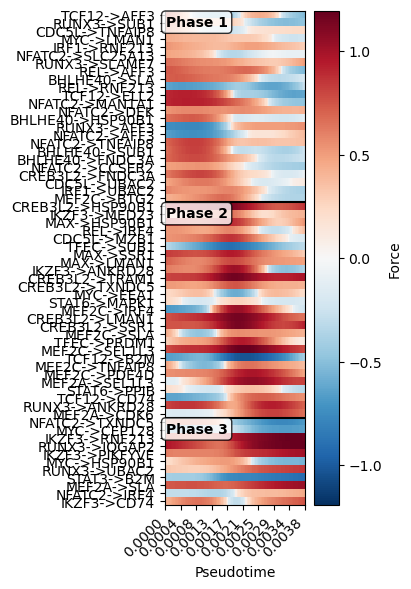

In [14]:
ordered_df, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_pb.force_curves,
    dtime=waves_pb.dtime,
    links=links,
    switch_pseudotimes=switch_pseudotimes,
)
plt.show()

In [ ]:
# selected links for plotting
pb_episodic_links = [(REL, AFF3), (REL, RNF213), (BHLHE40, SLA), (BHLHE40, HSP90B1), (BHLHE40, FNDC3A), (REL,IRF4), (TFEC,SUB1), (TFEC,PRDM1), (MAX, SSR1), (MAX, LMAN1), (CREB3L2,LMAN1), (CREB3L2,SSR1), (MEF2C, SEL1L3)]

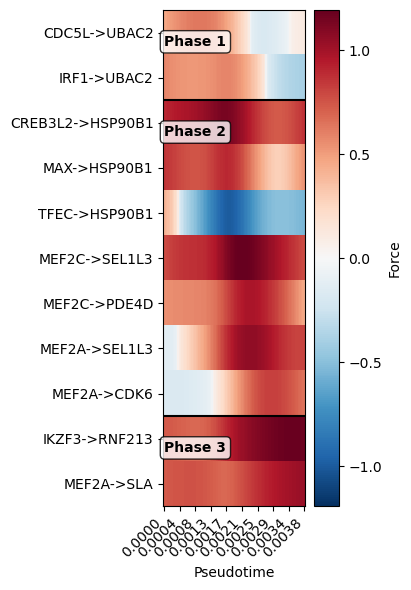

In [16]:
ordered_df_subset, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_pb.force_curves,
    dtime=waves_pb.dtime,
    links=pb_episodic_links,
    switch_pseudotimes=switch_pseudotimes,
)
fig.savefig(f"{config.OUTPUT_FOLDER}/pb_episodic_links_phase.svg",
            format='svg', bbox_inches='tight')
plt.show()

## GC links

In [17]:
# episodic links as (TF, target) tuples (built above)
links = sorted(episodic_links_tuples)

# 1) force curves for these links on the GC segment (0 -> 3), cached on its source
waves_gc = traj.waves()['GC']
waves_gc.compute_forces(links)


time_0    time_1    time_2    time_3    time_4    time_5  \
TF      Target                                                                 
BHLHE40 FNDC3A    0.683650  0.682579  0.681271  0.679734  0.677975  0.676002   
        SLC25A13  0.329939  0.333102  0.336073  0.338848  0.341422  0.343791   
        MZB1     -0.279951 -0.281570 -0.283147 -0.284686 -0.286191 -0.287663   
        IRF4      0.247559  0.260061  0.271924  0.283207  0.293952  0.304188   
        TRAM1     0.577145  0.578527  0.579716  0.580709  0.581508  0.582111   
...                    ...       ...       ...       ...       ...       ...   
MEF2A   CEP128   -0.165469 -0.167309 -0.169232 -0.171260 -0.173417 -0.175727   
        MED23    -0.262972 -0.264929 -0.266764 -0.268465 -0.270025 -0.271429   
        CDK6     -0.152778 -0.160898 -0.168835 -0.176687 -0.184537 -0.192459   
        EEA1     -0.141953 -0.135592 -0.129157 -0.122655 -0.116097 -0.109498   
        B2M      -0.151707 -0.154318 -0.156816 -0.159201 -0.161472 -0.163631   

                    time_6    time_7    time_8    time_9  ...   time_90  \
TF      Target                                            ...             
BHLHE40 FNDC3A    0.673824  0.671449  0.668886  0.666146  ...  0.300695   
        SLC25A13  0.345948  0.347887  0.349597  0.351070  ...  0.293290   
        MZB1     -0.289106 -0.290522 -0.291914 -0.293283  ...  0.211919   
        IRF4      0.313935  0.323204  0.332001  0.340322  ... -0.257949   
        TRAM1     0.582517  0.582727  0.582740  0.582555  ...  0.254041   
...                    ...       ...       ...       ...  ...       ...   
MEF2A   CEP128   -0.178215 -0.180905 -0.183823 -0.186992  ...  0.299644   
        MED23    -0.272665 -0.273717 -0.274564 -0.275185  ... -0.270004   
        CDK6     -0.200521 -0.208785 -0.217309 -0.226144  ...  0.241414   
        EEA1     -0.102883 -0.096287 -0.089761 -0.083386  ... -0.416007   
        B2M      -0.165676 -0.167608 -0.169427 -0.171133  ... -0.156671   

                   time_91   time_92   time_93   time_94   time_95   time_96  \
TF      Target                                                                 
BHLHE40 FNDC3A    0.299805  0.299212  0.298904  0.298865  0.299081  0.299537   
        SLC25A13  0.293947  0.294516  0.295002  0.295414  0.295757  0.296037   
        MZB1      0.211494  0.211131  0.210826  0.210574  0.210371  0.210215   
        IRF4     -0.255616 -0.253274 -0.250922 -0.248556 -0.246176 -0.243779   
        TRAM1     0.253427  0.252969  0.252662  0.252499  0.252473  0.252579   
...                    ...       ...       ...       ...       ...       ...   
MEF2A   CEP128    0.300504  0.301379  0.302266  0.303163  0.304069  0.304982   
        MED23    -0.275625 -0.280995 -0.286136 -0.291069 -0.295812 -0.300380   
        CDK6      0.240459  0.239525  0.238612  0.237720  0.236850  0.236001   
        EEA1     -0.416636 -0.417204 -0.417713 -0.418166 -0.418566 -0.418916   
        B2M      -0.163689 -0.170445 -0.176967 -0.183278 -0.189395 -0.195335   

                   time_97   time_98   time_99  
TF      Target                                  
BHLHE40 FNDC3A    0.300219  0.301113  0.302205  
        SLC25A13  0.296259  0.296428  0.296547  
        MZB1      0.210101  0.210025  0.209985  
        IRF4     -0.241365 -0.238930 -0.236474  
        TRAM1     0.252809  0.253159  0.253621  
...                    ...       ...       ...  
MEF2A   CEP128    0.305900  0.306822  0.307746  
        MED23    -0.304787 -0.309046 -0.313167  
        CDK6      0.235172  0.234362  0.233569  
        EEA1     -0.419219 -0.419476 -0.419691  
        B2M      -0.201110 -0.206732 -0.212211  

[560 rows x 100 columns]

In [18]:
# 2) GC phase boundaries = cell-state termination pseudotimes (2 phases)
sf = traj.state_frequency('GC', config.CELL_LABELS, colors=colors_cell_count)
switch_pseudotimes = [
    sf.termination_pseudotime(state, GC_post_bifurcation_window_indices)
    for state in ['ActB-3']
]


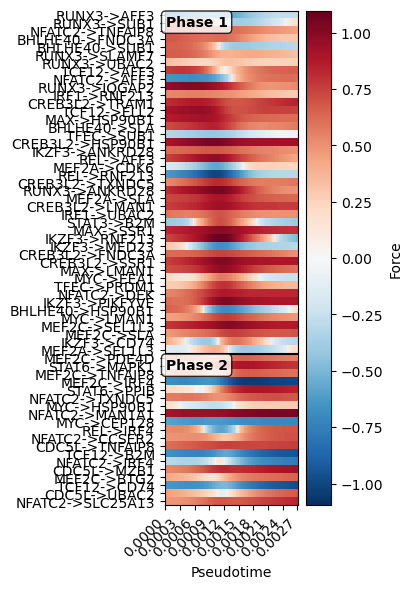

In [19]:
ordered_df, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_gc.force_curves,
    dtime=waves_gc.dtime,
    links=links,
    switch_pseudotimes=switch_pseudotimes,
)
plt.show()

In [ ]:
# selected links for plotting
gc_episodic_links = [nfatc2>tnfaip8, nfatc2>aff3, tcf12>aff3, ikzf3>rnf213, myc>eea1, myc>lman1, ikzf3>cd74, mef2c>irf4, nfatc2>irf4, nfatc2>slc25a13, cdc5l>mzb1, cdc5l>tnfaip8, myc> hsp90b1]

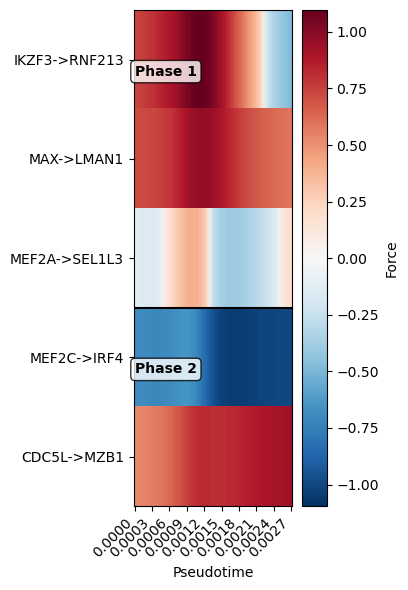

In [21]:
ordered_df_subset, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_gc.force_curves,
    dtime=waves_gc.dtime,
    links=gc_episodic_links,
    switch_pseudotimes=switch_pseudotimes,
)
fig.savefig(f"{config.OUTPUT_FOLDER}/gc_episodic_links_phase.svg",
            format='svg', bbox_inches='tight')
plt.show()